In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
import numpy as np

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using {device} device")
if device==torch.device("cuda"):print(torch.cuda.get_device_name(0))  # Nom du GPU


features=np.array(["5_o_Clock_Shadow","Arched_Eyebrows","Attractive",
          "Bags_Under_Eyes","Bald","Bangs","Big_Lips","Big_Nose",
          "Black_Hair","Blond_Hair","Blurry","Brown_Hair","Bushy_Eyebrows",
          "Chubby","Double_Chin","Eyeglasses","Goatee","Gray_Hair","Heavy_Makeup",
          "High_Cheekbones","Male","Mouth_Slightly_Open","Mustache","Narrow_Eyes",
          "No_Beard","Oval_Face","Pale_Skin","Pointy_Nose","Receding_Hairline","Rosy_Cheeks",
          "Sideburns","Smiling","Straight_Hair","Wavy_Hair","Wearing_Earrings","Wearing_Hat","Wearing_Lipstick",
          "Wearing_Necklace","Wearing_Necktie","Young"])

Using cpu device


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CVAE(nn.Module):
    def __init__(self, latent_dim=512, num_classes=40):
        super(CVAE, self).__init__()
        self.num_classes = num_classes
        
        self.enc_conv1 = nn.Conv2d(3 + num_classes, 64, kernel_size=4, stride=2, padding=1)
        self.enc_bn1 = nn.BatchNorm2d(64)
        self.enc_conv2 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
        self.enc_bn2 = nn.BatchNorm2d(128)
        self.enc_conv3 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)
        self.enc_bn3 = nn.BatchNorm2d(256)
        self.enc_conv4 = nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1)
        self.enc_bn4 = nn.BatchNorm2d(512)
        self.enc_conv5 = nn.Conv2d(512, 1024, kernel_size=4, stride=2, padding=1)
        self.enc_bn5 = nn.BatchNorm2d(1024)
        
        self.fc_mu = nn.Linear(1024 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(1024 * 4 * 4, latent_dim)
        
        self.dec_fc = nn.Linear(latent_dim + num_classes, 1024 * 4 * 4)
        
        self.dec_conv0 = nn.ConvTranspose2d(1024, 512, kernel_size=4, stride=2, padding=1)
        self.dec_bn0 = nn.BatchNorm2d(512)
        self.dec_conv1 = nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1)
        self.dec_bn1 = nn.BatchNorm2d(256)
        self.dec_conv2 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)
        self.dec_bn2 = nn.BatchNorm2d(128)
        self.dec_conv3 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        self.dec_bn3 = nn.BatchNorm2d(64)
        self.dec_conv4 = nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1)

    def encode(self, x, c):
        batch_size, _, h, w = x.size()
        c_expanded = c.view(batch_size, self.num_classes, 1, 1).expand(-1, -1, h, w)
        x = torch.cat([x, c_expanded], dim=1)
        
        x = F.leaky_relu(self.enc_bn1(self.enc_conv1(x)), 0.2)
        x = F.leaky_relu(self.enc_bn2(self.enc_conv2(x)), 0.2)
        x = F.leaky_relu(self.enc_bn3(self.enc_conv3(x)), 0.2)
        x = F.leaky_relu(self.enc_bn4(self.enc_conv4(x)), 0.2)
        x = F.leaky_relu(self.enc_bn5(self.enc_conv5(x)), 0.2)
        x = x.view(x.size(0), -1)
        
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c):
        z = torch.cat([z, c], dim=1)
        z = self.dec_fc(z)
        z = z.view(z.size(0), 1024, 4, 4)
        
        z = F.relu(self.dec_bn0(self.dec_conv0(z)))
        z = F.relu(self.dec_bn1(self.dec_conv1(z)))
        z = F.relu(self.dec_bn2(self.dec_conv2(z)))
        z = F.relu(self.dec_bn3(self.dec_conv3(z)))
        z = torch.sigmoid(self.dec_conv4(z))
        return z

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z, c)
        return x_recon, mu, logvar


def train(dataloader, model, optimizer, device, beta=1.0):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X = X.to(device)
        y = y.to(device)
        
        optimizer.zero_grad()
        
        pred, mu, log_sigma = model(X, y)
        reconstruction_loss = F.l1_loss(pred, X, reduction='sum')
        kl = -0.5 * torch.sum(1 + log_sigma - mu.pow(2) - log_sigma.exp())
        loss = reconstruction_loss + beta * kl

        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss_val, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss_val:>7f}  [{current:>5d}/{size:>5d}]")


def test(dataloader, model, device):
    num_batches = len(dataloader)
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)
            pred, _, _ = model(X, y)
            test_loss += F.l1_loss(pred, X, reduction='sum').item()
    test_loss /= len(dataloader.dataset)
    print(f"Test loss (L1): {test_loss:>8f} \n")

In [3]:
model = CVAE().to(device)


weights = torch.load("CNN_features_128_model_20260403-080330.pth", weights_only=True, map_location=torch.device('cpu'))

# 3. Appliquer les poids au modèle
model.load_state_dict(weights)

# 4. Passer en mode évaluation
model.eval()

CVAE(
  (enc_conv1): Conv2d(43, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_conv2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_conv3): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_conv4): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_bn4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_conv5): Conv2d(512, 1024, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_bn5): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc_mu): Linear(in_features=16384, out_features=512, bias=True)
  (fc_logvar): Linear(in_features=16384, out_

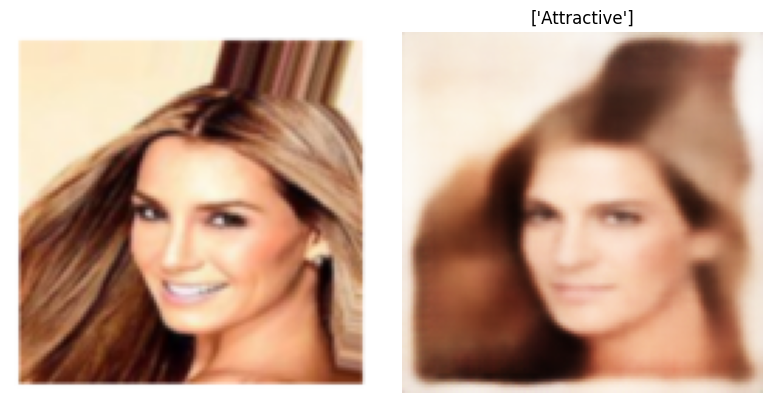

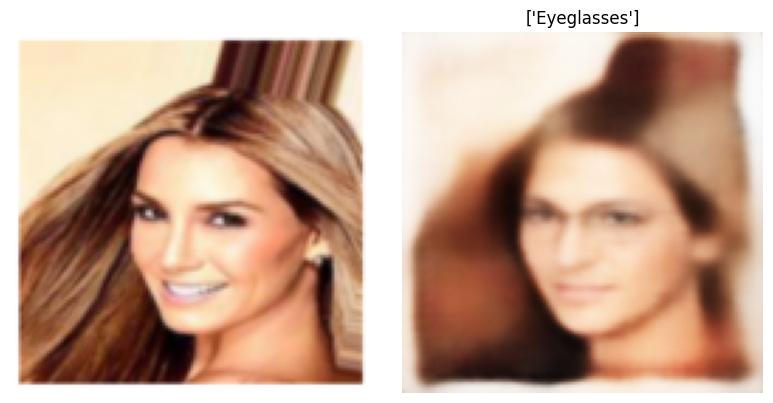

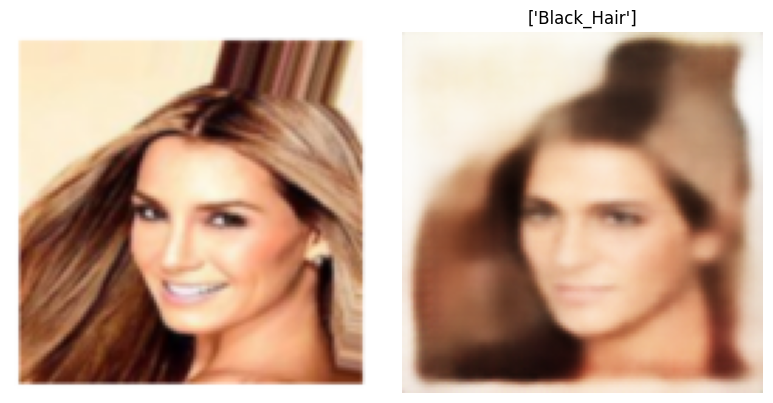

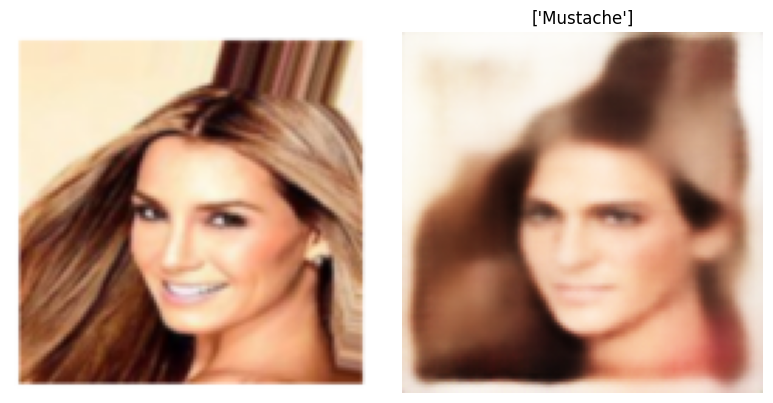

In [4]:
from PIL import Image

import torchvision.transforms as T

for i in (2, 15,8,22):
  image =  Image.open("femme.png").convert("RGB")


  transform = T.Compose([
      T.Resize((128, 128)),
      T.ToTensor(),
  ])

  img_tensor = transform(image).unsqueeze(0).to(device)

    
  feature = [0] * 40
  feature[i] = 1
  feature_tensor = torch.tensor(feature, dtype=torch.float32).unsqueeze(0).to(device)


  with torch.no_grad():
      pred, _, _ = model(img_tensor, feature_tensor)

  pred = pred.reshape(1, 3, 128,128)

  fig, axes = plt.subplots(1, 2, figsize=(8, 4))

  axes[0].imshow(img_tensor.squeeze().permute(1, 2, 0).cpu().squeeze())
  axes[0].axis("off")

  axes[1].imshow(pred.squeeze().permute(1, 2, 0).detach().cpu().squeeze())
  axes[1].axis("off")
  axes[1].set_title(features[np.array(feature)==1])

  plt.tight_layout()
  plt.show()

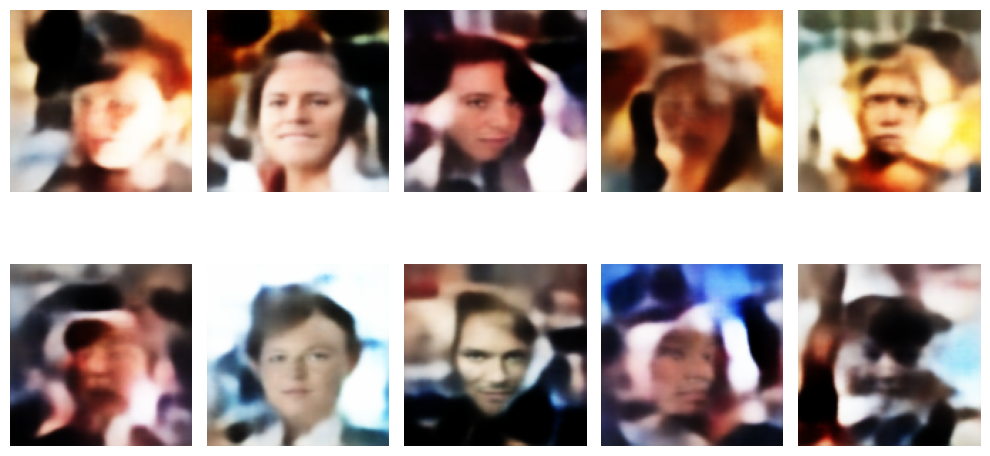

In [17]:


latent_dim = 512
fig, axes = plt.subplots(2, 5, figsize=(10, 6))
axes = axes.flatten()

for i in range(10):
    # Génère mu et logvar aléatoirement
    mean = torch.randn(1, latent_dim).to(device)
    log_var = torch.randn(1, latent_dim).to(device)
    feature=[0]*40
    feature[4]=1
    feature = torch.tensor(feature, dtype=torch.float32).unsqueeze(0).to(device)
    # Reparameterize
    with torch.no_grad():
        z = model.reparameterize(mean, log_var)
        y = model.decode(z,feature)

    # Format image
    image = y.cpu().squeeze().numpy()
    image = np.transpose(image, (1, 2, 0))  # (H, W, C)

    axes[i].imshow(image, cmap="gray")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


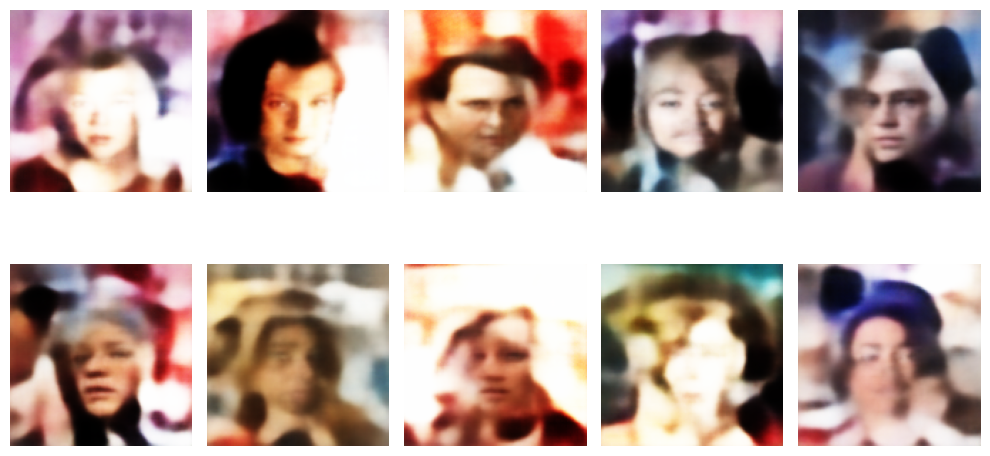

In [6]:


latent_dim = 512
fig, axes = plt.subplots(2, 5, figsize=(10, 6))
axes = axes.flatten()

for i in range(10):
    # Génère mu et logvar aléatoirement
    mean = torch.randn(1, latent_dim).to(device)
    log_var = torch.randn(1, latent_dim).to(device)
    feature=[0]*40
    feature[9]=1
    feature = torch.tensor(feature, dtype=torch.float32).unsqueeze(0).to(device)
    # Reparameterize
    with torch.no_grad():
        z = model.reparameterize(mean, log_var)
        y = model.decode(z,feature)

    # Format image
    image = y.cpu().squeeze().numpy()
    image = np.transpose(image, (1, 2, 0))  # (H, W, C)

    axes[i].imshow(image, cmap="gray")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


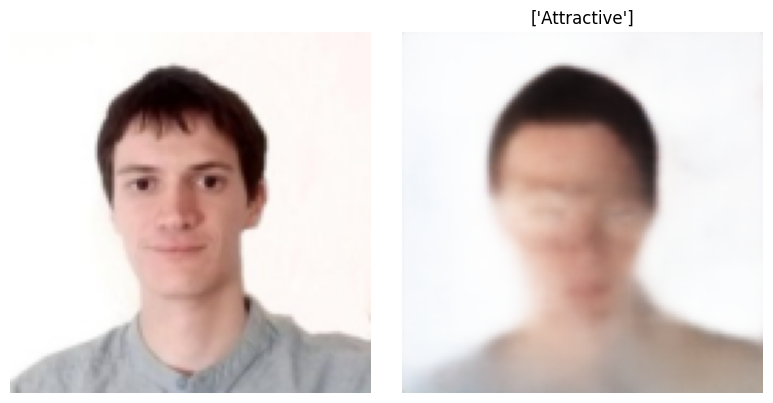

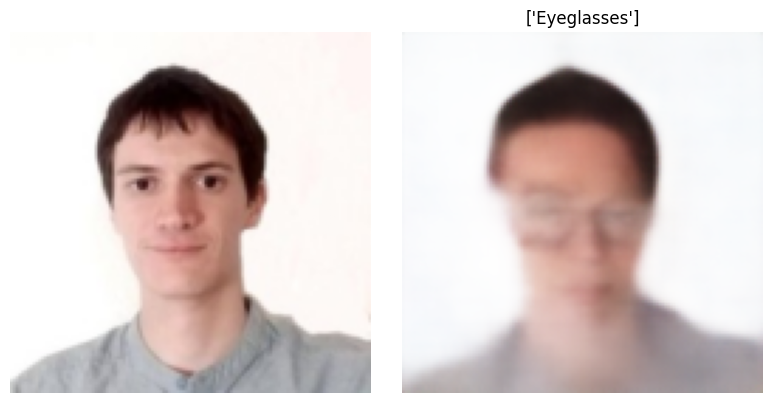

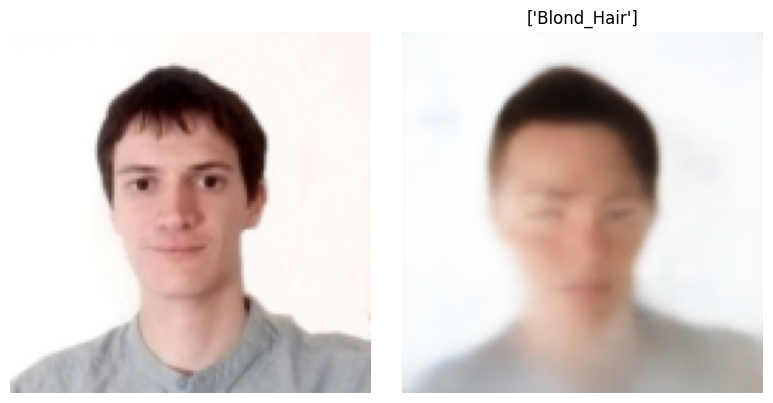

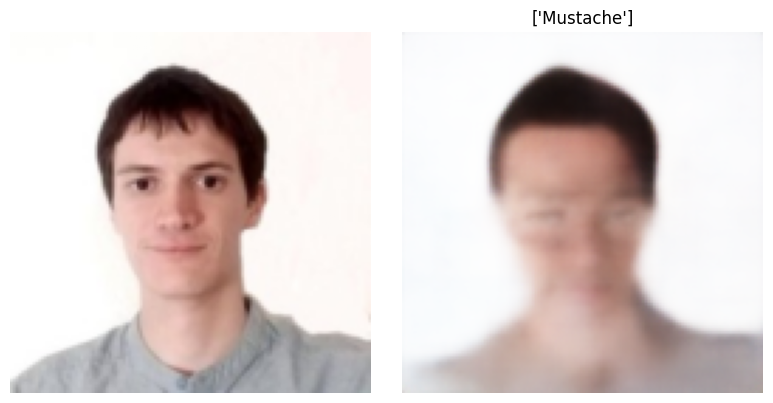

In [7]:
from PIL import Image

import torchvision.transforms as T

for i in (2, 15,9,22):
  image =  Image.open("moi.jpg").convert("RGB")


  transform = T.Compose([
      T.Resize((128, 128)),
      T.ToTensor(),
  ])

  img_tensor = transform(image).unsqueeze(0).to(device)

  feature = [0] * 40
  feature[i] = 1
  feature_tensor = torch.tensor(feature, dtype=torch.float32).unsqueeze(0).to(device)


  with torch.no_grad():
      pred, _, _ = model(img_tensor, feature_tensor)

  pred = pred.reshape(1, 3, 128,128)

  fig, axes = plt.subplots(1, 2, figsize=(8, 4))

  axes[0].imshow(img_tensor.squeeze().permute(1, 2, 0).cpu().squeeze())
  axes[0].axis("off")

  axes[1].imshow(pred.squeeze().permute(1, 2, 0).detach().cpu().squeeze())
  axes[1].axis("off")
  axes[1].set_title(features[np.array(feature)==1])

  plt.tight_layout()
  plt.show()

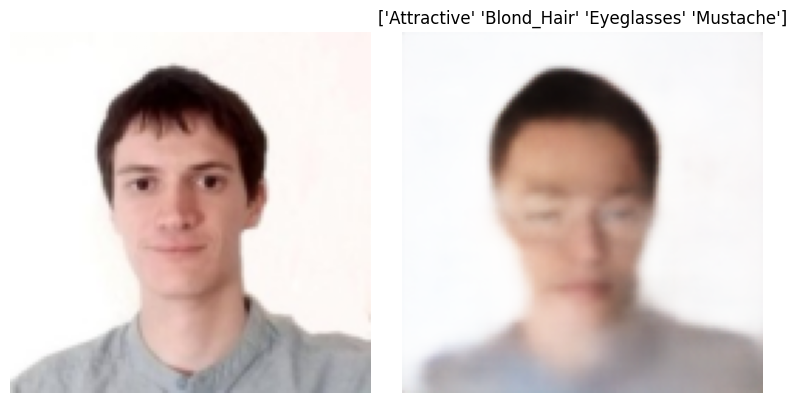

In [8]:
from PIL import Image

import torchvision.transforms as T
feature = [0] * 40
  
for i in (2, 15,9,22):feature[i] = 1
image =  Image.open("moi.jpg").convert("RGB")


transform = T.Compose([
  T.Resize((128, 128)),
  T.ToTensor(),
])

img_tensor = transform(image).unsqueeze(0).to(device)


feature_tensor = torch.tensor(feature, dtype=torch.float32).unsqueeze(0).to(device)


with torch.no_grad():
  pred, _, _ = model(img_tensor, feature_tensor)

pred = pred.reshape(1, 3, 128,128)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(img_tensor.squeeze().permute(1, 2, 0).cpu().squeeze())
axes[0].axis("off")

axes[1].imshow(pred.squeeze().permute(1, 2, 0).detach().cpu().squeeze())
axes[1].axis("off")
axes[1].set_title(features[np.array(feature)==1])

plt.tight_layout()
plt.show()